# Loan Prediction - Classification

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('LoansTrainingSet.csv')

C:\Users\Monster\AppData\Local\Temp\ipykernel_9256\841172785.py:1: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('LoansTrainingSet.csv')


In [3]:
df.head()

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Years in current job,Home Ownership,Annual Income,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,000025bb-5694-4cff-b17d-192b1a98ba44,5ebc8bb1-5eb9-4404-b11b-a6eebc401a19,Fully Paid,11520,Short Term,741.0,10+ years,Home Mortgage,33694.0,Debt Consolidation,$584.03,12.3,41.0,10,0,6760,16056,0.0,0.0
1,00002c49-3a29-4bd4-8f67-c8f8fbc1048c,927b388d-2e01-423f-a8dc-f7e42d668f46,Fully Paid,3441,Short Term,734.0,4 years,Home Mortgage,42269.0,other,"$1,106.04",26.3,NaN,17,0,6262,19149,0.0,0.0
2,00002d89-27f3-409b-aa76-90834f359a65,defce609-c631-447d-aad6-1270615e89c4,Fully Paid,21029,Short Term,747.0,10+ years,Home Mortgage,90126.0,Debt Consolidation,"$1,321.85",28.8,NaN,5,0,20967,28335,0.0,0.0
3,00005222-b4d8-45a4-ad8c-186057e24233,070bcecb-aae7-4485-a26a-e0403e7bb6c5,Fully Paid,18743,Short Term,747.0,10+ years,Own Home,38072.0,Debt Consolidation,$751.92,26.2,NaN,9,0,22529,43915,0.0,0.0
4,0000757f-a121-41ed-b17b-162e76647c1f,dde79588-12f0-4811-bab0-e2b07f633fcd,Fully Paid,11731,Short Term,746.0,4 years,Rent,50025.0,Debt Consolidation,$355.18,11.5,NaN,12,0,17391,37081,0.0,0.0


In [4]:
df.describe()

,Current Loan Amount,Credit Score,Annual Income,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Bankruptcies,Tax Liens
count,2.569840e+05,195308.000000,1.953080e+05,256984.000000,116601.000000,256984.000000,256984.000000,2.569840e+05,256455.000000,256961.000000
mean,1.371331e+07,1251.116099,7.195272e+04,18.290195,34.881450,11.106267,0.156628,1.540656e+04,0.110316,0.027203
std,3.438131e+07,1762.016848,5.887757e+04,7.075747,21.854165,4.982982,0.460731,1.966506e+04,0.336229,0.245950
min,5.050000e+02,585.000000,0.000000e+00,3.400000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,8.299000e+03,714.000000,4.432100e+04,13.500000,16.000000,8.000000,0.000000,5.974000e+03,0.000000,0.000000
50%,1.429800e+04,733.000000,6.124200e+04,17.000000,32.000000,10.000000,0.000000,1.107800e+04,0.000000,0.000000
75%,2.436700e+04,744.000000,8.646200e+04,21.700000,51.000000,14.000000,0.000000,1.931900e+04,0.000000,0.000000
max,1.000000e+08,7510.000000,8.713547e+06,70.500000,176.000000,76.000000,11.000000,1.731412e+06,7.000000,11.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256984 entries, 0 to 256983
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Loan ID                       256984 non-null  object 
 1   Customer ID                   256984 non-null  object 
 2   Loan Status                   256984 non-null  object 
 3   Current Loan Amount           256984 non-null  int64  
 4   Term                          256984 non-null  object 
 5   Credit Score                  195308 non-null  float64
 6   Years in current job          245508 non-null  object 
 7   Home Ownership                256984 non-null  object 
 8   Annual Income                 195308 non-null  float64
 9   Purpose                       256984 non-null  object 
 10  Monthly Debt                  256984 non-null  object 
 11  Years of Credit History       256984 non-null  float64
 12  Months since last delinquent  116601 non-nul

In [6]:
df.isnull().sum()

Loan ID                              0
Customer ID                          0
Loan Status                          0
Current Loan Amount                  0
Term                                 0
Credit Score                     61676
Years in current job             11476
Home Ownership                       0
Annual Income                    61676
Purpose                              0
Monthly Debt                         0
Years of Credit History              0
Months since last delinquent    140383
Number of Open Accounts              0
Number of Credit Problems            0
Current Credit Balance               0
Maximum Open Credit                  0
Bankruptcies                       529
Tax Liens                           23
dtype: int64

In [7]:
df.fillna(0, inplace=True) #boş olan sutunları 0 la doldurdum 

In [8]:
df.isnull().sum()

Loan ID                         0
Customer ID                     0
Loan Status                     0
Current Loan Amount             0
Term                            0
Credit Score                    0
Years in current job            0
Home Ownership                  0
Annual Income                   0
Purpose                         0
Monthly Debt                    0
Years of Credit History         0
Months since last delinquent    0
Number of Open Accounts         0
Number of Credit Problems       0
Current Credit Balance          0
Maximum Open Credit             0
Bankruptcies                    0
Tax Liens                       0
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256984 entries, 0 to 256983
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Loan ID                       256984 non-null  object 
 1   Customer ID                   256984 non-null  object 
 2   Loan Status                   256984 non-null  object 
 3   Current Loan Amount           256984 non-null  int64  
 4   Term                          256984 non-null  object 
 5   Credit Score                  256984 non-null  float64
 6   Years in current job          256984 non-null  object 
 7   Home Ownership                256984 non-null  object 
 8   Annual Income                 256984 non-null  float64
 9   Purpose                       256984 non-null  object 
 10  Monthly Debt                  256984 non-null  object 
 11  Years of Credit History       256984 non-null  float64
 12  Months since last delinquent  256984 non-nul

In [10]:
df.columns

Index(['Loan ID', 'Customer ID', 'Loan Status', 'Current Loan Amount', 'Term',
       'Credit Score', 'Years in current job', 'Home Ownership',
       'Annual Income', 'Purpose', 'Monthly Debt', 'Years of Credit History',
       'Months since last delinquent', 'Number of Open Accounts',
       'Number of Credit Problems', 'Current Credit Balance',
       'Maximum Open Credit', 'Bankruptcies', 'Tax Liens'],
      dtype='object')

In [11]:
df.shape

(256984, 19)

In [12]:
df.corr(numeric_only=True) # correlation

,Current Loan Amount,Credit Score,Annual Income,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Bankruptcies,Tax Liens
Current Loan Amount,1.000000,-0.055070,0.135144,0.014725,-0.003187,-0.003094,-0.000062,0.003138,0.003577,-0.003067
Credit Score,-0.055070,1.000000,0.141841,-0.009599,-0.001112,0.006179,0.001593,-0.003444,-0.001922,0.004220
Annual Income,0.135144,0.141841,1.000000,0.109839,0.012492,0.104177,-0.008785,0.208322,-0.032209,0.029710
Years of Credit History,0.014725,-0.009599,0.109839,1.000000,0.086489,0.128033,0.061251,0.201001,0.061737,0.020911
Months since last delinquent,-0.003187,-0.001112,0.012492,0.086489,1.000000,0.035319,0.071807,-0.065335,0.047202,0.031175
Number of Open Accounts,-0.003094,0.006179,0.104177,0.128033,0.035319,1.000000,-0.013731,0.222763,-0.022565,0.005754
Number of Credit Problems,-0.000062,0.001593,-0.008785,0.061251,0.071807,-0.013731,1.000000,-0.103814,0.755787,0.584912
Current Credit Balance,0.003138,-0.003444,0.208322,0.201001,-0.065335,0.222763,-0.103814,1.000000,-0.117839,-0.011119
Bankruptcies,0.003577,-0.001922,-0.032209,0.061737,0.047202,-0.022565,0.755787,-0.117839,1.000000,0.046229
Tax Liens,-0.003067,0.004220,0.029710,0.020911,0.031175,0.005754,0.584912,-0.011119,0.046229,1.000000


<Axes: >

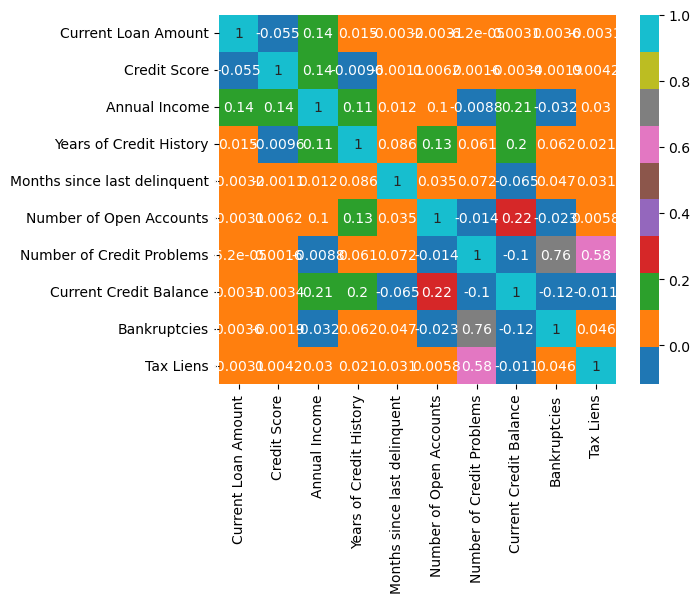

In [13]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='tab10')

In [14]:
df.head()

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Years in current job,Home Ownership,Annual Income,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,000025bb-5694-4cff-b17d-192b1a98ba44,5ebc8bb1-5eb9-4404-b11b-a6eebc401a19,Fully Paid,11520,Short Term,741.0,10+ years,Home Mortgage,33694.0,Debt Consolidation,$584.03,12.3,41.0,10,0,6760,16056,0.0,0.0
1,00002c49-3a29-4bd4-8f67-c8f8fbc1048c,927b388d-2e01-423f-a8dc-f7e42d668f46,Fully Paid,3441,Short Term,734.0,4 years,Home Mortgage,42269.0,other,"$1,106.04",26.3,0.0,17,0,6262,19149,0.0,0.0
2,00002d89-27f3-409b-aa76-90834f359a65,defce609-c631-447d-aad6-1270615e89c4,Fully Paid,21029,Short Term,747.0,10+ years,Home Mortgage,90126.0,Debt Consolidation,"$1,321.85",28.8,0.0,5,0,20967,28335,0.0,0.0
3,00005222-b4d8-45a4-ad8c-186057e24233,070bcecb-aae7-4485-a26a-e0403e7bb6c5,Fully Paid,18743,Short Term,747.0,10+ years,Own Home,38072.0,Debt Consolidation,$751.92,26.2,0.0,9,0,22529,43915,0.0,0.0
4,0000757f-a121-41ed-b17b-162e76647c1f,dde79588-12f0-4811-bab0-e2b07f633fcd,Fully Paid,11731,Short Term,746.0,4 years,Rent,50025.0,Debt Consolidation,$355.18,11.5,0.0,12,0,17391,37081,0.0,0.0


In [15]:
df['Customer ID'].value_counts() #  Müşteri Kimliğine göre o id sahip müşterinin kaç kredisi var 

Customer ID
a96104f4-2f44-4112-82b9-75605d44dac3    4
abbb7bf6-908f-4500-bc46-a6b1b87d3d8a    4
0d1af0aa-9442-48ee-aa88-19bc3b5f2513    4
107aa25a-f027-444e-9a11-ab4bd884df85    4
cd3f6794-02bd-482b-a698-d03c0ab02f3d    4
                                       ..
796fa982-4c36-404f-91d8-9716ed267bad    1
f9666770-56c1-4635-afd4-657c7a63593a    1
da9c63fb-50c3-41a8-b495-eb13d792bb9b    1
b5fce597-d948-4b7e-b181-ad30248a1bfb    1
97281336-1e45-41d2-acb2-263ce56a590e    1
Name: count, Length: 215700, dtype: int64

In [16]:
df['Loan Status'].value_counts() #Kredi Durumu: Kredinin geri ödenip ödenmediğini veya temerrüde düşüp düşmediğini gösterir ödenmiş ve ödenmemiş veriler

Loan Status
Fully Paid     176191
Charged Off     80793
Name: count, dtype: int64

In [17]:
df['Current Loan Amount'].value_counts() # Tamamen ödenen veya temerrüde düşen kredi tutarı

Current Loan Amount
99999999    35210
9820           59
9793           58
10132          56
10025          54
            ...  
26821           1
21333           1
1235            1
18028           1
17940           1
Name: count, Length: 27347, dtype: int64

In [18]:
df['Term'].value_counts() #Kısa vadeli veya uzun vadeli bir kredi olduğunu belirtir

Term
Short Term    192632
Long Term      64352
Name: count, dtype: int64

In [19]:
df['Credit Score'].value_counts() #Kredi Puanı: Borçlunun kredi geçmişinin riskliliğini gösteren 0 ile 800 arasında bir değer.

Credit Score
0.0       61676
747.0      5669
740.0      5537
741.0      5499
746.0      5486
          ...  
6070.0        3
5980.0        3
5910.0        3
5930.0        2
5860.0        1
Name: count, Length: 335, dtype: int64

In [20]:
# 800'den büyük olan değerleri 10'a bölerek normale döndürüyoruz
df.loc[df['Credit Score'] > 800, 'Credit Score'] = df['Credit Score'] / 10

print(df['Credit Score'].value_counts().sort_index(ascending=False).head())


Credit Score
751.0    2404
750.0    3928
749.0    2724
748.0    4926
747.0    5862
Name: count, dtype: int64


In [21]:
df['Credit Score'].value_counts()

Credit Score
0.0      61676
740.0     5877
747.0     5862
741.0     5843
746.0     5736
         ...  
590.0       22
589.0       22
585.0       21
593.0       19
591.0       18
Name: count, Length: 168, dtype: int64

In [22]:
df['Years in current job'].value_counts() #Müşterinin mevcut işte kaç yıldır çalıştığını gösterir

Years in current job
10+ years    78896
2 years      23462
< 1 year     21012
3 years      20659
5 years      17864
1 year       16746
4 years      16166
6 years      14597
7 years      13968
8 years      12206
0            11476
9 years       9932
Name: count, dtype: int64

In [23]:
df['Purpose'].value_counts() #Amaç: Kredinin amacının açıklaması.

Purpose
Debt Consolidation      203911
Home Improvements        14915
other                    14268
Other                     9667
Business Loan             4712
Buy a Car                 3276
Medical Bills             2868
Take a Trip               1570
Buy House                 1530
Educational Expenses       267
Name: count, dtype: int64

In [24]:
df['Purpose']=df['Purpose'].replace(['other'],['Other'])

In [25]:
df['Purpose'].value_counts()

Purpose
Debt Consolidation      203911
Other                    23935
Home Improvements        14915
Business Loan             4712
Buy a Car                 3276
Medical Bills             2868
Take a Trip               1570
Buy House                 1530
Educational Expenses       267
Name: count, dtype: int64

In [26]:
df['Monthly Debt'].value_counts() #Müşterinin mevcut kredileri için aylık ödemesi

Monthly Debt
$0.00         254
$636.87        12
$679.66        12
$847.85        12
$838.10        12
             ... 
$899.24         1
$339.53         1
$1,152.39       1
$2,711.19       1
$2,525.82       1
Name: count, Length: 129115, dtype: int64

In [27]:
# 1. '$' işaretini ve ',' (virgül) işaretini kaldırıp sayıya (float) çeviriyoruz
df['Monthly Debt'] = df['Monthly Debt'].str.replace('$', '').str.replace(',', '').astype(float)

In [28]:
df['Monthly Debt'].value_counts() #Aylık Borç: Müşterinin mevcut kredileri için aylık ödemesi temizlenmiş hali

Monthly Debt
0.00       254
636.87      12
679.66      12
847.85      12
838.10      12
          ... 
899.24       1
339.53       1
1152.39      1
2711.19      1
2525.82      1
Name: count, Length: 129115, dtype: int64

In [29]:
df['Years of Credit History'].value_counts() #Kredi Geçmişi Yılları: Müşterinin kredi geçmişine ilk girişten bu yana geçen yıllar

Years of Credit History
16.0    3563
15.0    3379
17.0    3080
16.5    2963
14.0    2954
        ... 
52.8       1
54.6       1
3.7        1
65.8       1
60.7       1
Name: count, Length: 541, dtype: int64

In [30]:
df['Months since last delinquent'].value_counts() #son ödeme gecikmesinden bu yana geçen aylar

Months since last delinquent
0.0      140914
12.0       2224
14.0       2196
15.0       2189
8.0        2164
          ...  
122.0         1
98.0          1
143.0         1
140.0         1
119.0         1
Name: count, Length: 131, dtype: int64

In [31]:
df['Number of Open Accounts'].value_counts() #açık hesap sayısı

Number of Open Accounts
9     24412
10    23306
8     23140
11    21577
7     20851
12    19056
6     17454
13    15987
14    13649
5     12232
15    10833
16     8982
17     7258
4      7225
18     5801
19     4706
20     3612
3      3362
21     2815
22     2207
23     1725
24     1371
2      1104
25     1011
26      746
27      580
28      404
29      303
30      236
31      207
32      181
33      113
34      104
35       79
36       61
37       58
38       41
1        37
39       33
40       26
41       24
42       14
45        9
43        9
47        7
0         5
44        5
76        4
50        3
53        3
46        3
48        3
55        2
52        2
58        2
56        1
49        1
51        1
54        1
Name: count, dtype: int64

In [32]:
df['Current Credit Balance'].value_counts() #Mevcut Kredi Bakiyesi: Müşterinin mevcut toplam borcu

Current Credit Balance
0         1565
6746        32
3420        32
6259        30
6539        29
          ... 
34123        1
132138       1
77778        1
52618        1
35089        1
Name: count, Length: 45704, dtype: int64

In [33]:
df['Maximum Open Credit'].value_counts() #Maksimum Açık Kredi: Tüm kredi kaynakları için maksimum kredi limitidir

Maximum Open Credit
0        1597
0         234
10180      19
15662      19
14770      19
         ... 
17558       1
42753       1
29185       1
36222       1
62371       1
Name: count, Length: 87188, dtype: int64

In [34]:
df['Bankruptcies'].value_counts() #İflaslar: İflasların sayısı

Bankruptcies
0.0    230190
1.0     25605
2.0       957
3.0       180
4.0        33
5.0        15
6.0         3
7.0         1
Name: count, dtype: int64

In [35]:
df['Tax Liens'].value_counts() #Vergi İpotekleri: Vergi ipotekleri sayısı.

Tax Liens
0.0     252345
1.0       3276
2.0        872
3.0        247
4.0        124
5.0         61
6.0         30
9.0         10
8.0          8
7.0          6
10.0         3
11.0         2
Name: count, dtype: int64

In [36]:
#import pandas as pd

# 1. Adım: Tüm tablodaki sayısal olmayan karakterleri temizle
# Sayı, nokta (.) ve eksi (-) dışındaki her şeyi temizler ($, virgül vb. gider)
#df = df.replace(r'[^0-9.-]', '', regex=True)

# 2. Adım: Boş metinleri gerçek boşluk (NaN) yap
#df = df.replace('', pd.NA)

# 3. Adım: Sayıya çevrilebilen her şeyi sayıya çevir
# errors='coerce' : Sayıya dönüşmeyen (saf metin) yerleri boş (NaN) yapar
#df = df.apply(pd.to_numeric, errors='coerce')

# 4. Adım: Boş verileri 0 ile doldur ve her şeyi INT yap
# Not: Eğer ondalıklı sayıların kalmasını istiyorsan .astype(int) kısmını sil
#df = df.fillna(0).astype(int)

# 5. Sonucu kontrol et
#print(df.info())


In [37]:
#classification

In [38]:
#x = x.select_dtypes(include=['number'])

In [39]:
df['Loan Status'] = df['Loan Status'].map({'Fully Paid': 1, 'Charged Off': 0})

In [40]:
#x = df.drop(['Loan ID', 'Customer ID', 'Loan Status'], axis=1)

In [41]:
x = df.drop('Loan Status', axis=1)
y = df['Loan Status']

In [42]:
#x = pd.get_dummies(x, drop_first=True)

In [43]:
x.shape

(256984, 18)

In [44]:
x.head()

,Loan ID,Customer ID,Current Loan Amount,Term,Credit Score,Years in current job,Home Ownership,Annual Income,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,000025bb-5694-4cff-b17d-192b1a98ba44,5ebc8bb1-5eb9-4404-b11b-a6eebc401a19,11520,Short Term,741.0,10+ years,Home Mortgage,33694.0,Debt Consolidation,584.03,12.3,41.0,10,0,6760,16056,0.0,0.0
1,00002c49-3a29-4bd4-8f67-c8f8fbc1048c,927b388d-2e01-423f-a8dc-f7e42d668f46,3441,Short Term,734.0,4 years,Home Mortgage,42269.0,Other,1106.04,26.3,0.0,17,0,6262,19149,0.0,0.0
2,00002d89-27f3-409b-aa76-90834f359a65,defce609-c631-447d-aad6-1270615e89c4,21029,Short Term,747.0,10+ years,Home Mortgage,90126.0,Debt Consolidation,1321.85,28.8,0.0,5,0,20967,28335,0.0,0.0
3,00005222-b4d8-45a4-ad8c-186057e24233,070bcecb-aae7-4485-a26a-e0403e7bb6c5,18743,Short Term,747.0,10+ years,Own Home,38072.0,Debt Consolidation,751.92,26.2,0.0,9,0,22529,43915,0.0,0.0
4,0000757f-a121-41ed-b17b-162e76647c1f,dde79588-12f0-4811-bab0-e2b07f633fcd,11731,Short Term,746.0,4 years,Rent,50025.0,Debt Consolidation,355.18,11.5,0.0,12,0,17391,37081,0.0,0.0


In [45]:
#y.head()

 #boş verileri 0 ile doldurduğum için böyle gözüküyor ortalama veya orta değerle doldursaydım her müşteri aynı olur diye düşündüm evi olan var olmayan var ipoteği olan var olmayan var gibi gibi

In [46]:
#from sklearn.model_selection import train_test_split
#x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42,stratify=y)

In [47]:
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import BernoulliNB

In [48]:
g=GaussianNB()
b=BernoulliNB()

In [49]:
# 1. Adım: x içindeki sadece sayısal (int ve float) sütunları otomatik seç
# Bu işlem 'Loan ID', 'Customer ID' gibi metinleri (object) otomatik olarak dışarıda bırakır.
x = x.select_dtypes(include=['number'])

# 2. Adım: x içindeki boş (NaN) değerleri doldur (Yoksa model yine hata verir)
x = x.fillna(0)

# 3. Adım: Train-Test Split işlemini YENİDEN yap
# Sütun sayısı değiştiği için veriyi tekrar bölmemiz şart.
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

# 4. Adım: Modeli eğit
from sklearn.naive_bayes import GaussianNB
g = GaussianNB()
g.fit(x_train, y_train.values.ravel())

print("Model başarıyla eğitildi!")


Model başarıyla eğitildi!


In [50]:
b.fit(x_train,y_train)

,alpha,1.0
,force_alpha,True
,binarize,0.0
,fit_prior,True
,class_prior,None


In [51]:
gtahmin=g.predict(x_test)

In [52]:
btahmin=g.predict(x_test)

In [53]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [54]:
accuracy_score(y_test,gtahmin)

0.44889779559118237

In [55]:
confusion_matrix(y_test,gtahmin)

array([[16147,    14],
       [28311,  6925]])

In [56]:
print(classification_report(y_test,gtahmin))

              precision    recall  f1-score   support

           0       0.36      1.00      0.53     16161
           1       1.00      0.20      0.33     35236

    accuracy                           0.45     51397
   macro avg       0.68      0.60      0.43     51397
weighted avg       0.80      0.45      0.39     51397



<Axes: >

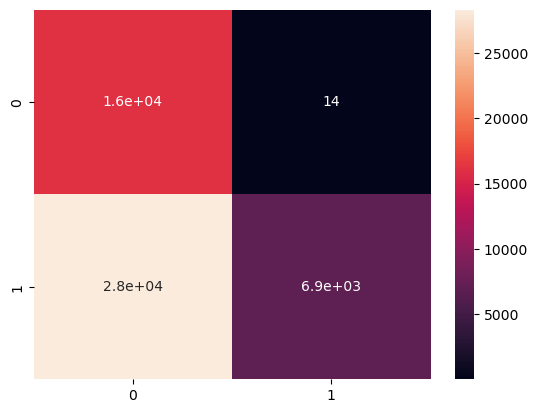

In [57]:
sns.heatmap(confusion_matrix(y_test,gtahmin), annot=True)

In [58]:
y.value_counts()

Loan Status
1    176191
0     80793
Name: count, dtype: int64

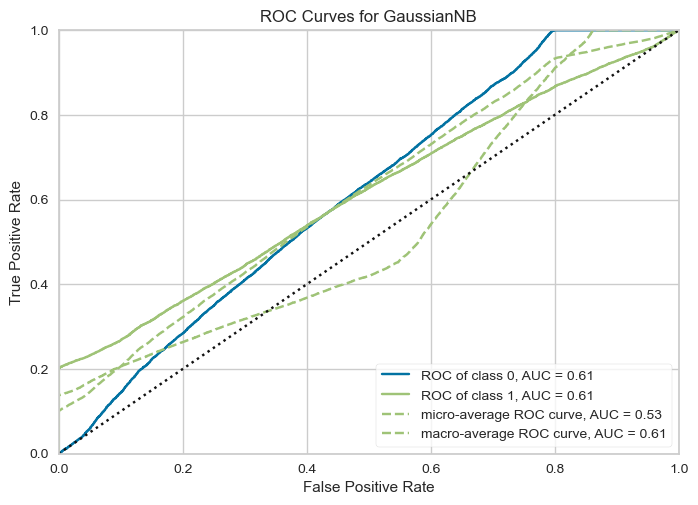

In [59]:
from sklearn.model_selection import train_test_split
from yellowbrick.classifier import roc_auc
from sklearn.naive_bayes import GaussianNB

# 1. Veriyi bölerken 'stratify=y' ekleyerek her iki sınıfın da dağılmasını sağla
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42, stratify=y)

# 2. Şimdi görselleştiriciyi tekrar dene
visualizer = roc_auc(GaussianNB(), x_train, y_train, x_test, y_test)


In [60]:
accuracy_score(y_test,btahmin)

0.36336751172247406

In [61]:
confusion_matrix(y_test,btahmin)

array([[13948,  2211],
       [30510,  4728]])

In [62]:
print(classification_report(y_test,btahmin))

              precision    recall  f1-score   support

           0       0.31      0.86      0.46     16159
           1       0.68      0.13      0.22     35238

    accuracy                           0.36     51397
   macro avg       0.50      0.50      0.34     51397
weighted avg       0.57      0.36      0.30     51397



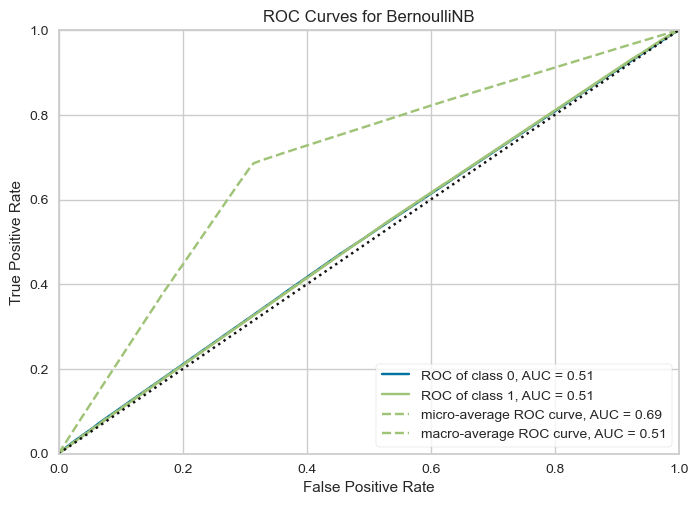

In [63]:
from yellowbrick.classifier import roc_auc
from yellowbrick.datasets import load_spam

visualizer= roc_auc(BernoulliNB(),x_train, y_train)

In [64]:
from sklearn.linear_model import LogisticRegression

In [65]:
L= LogisticRegression()

In [66]:
L.fit(x_train,y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [67]:
Ltahmin=L.predict(x_test)

In [68]:
accuracy_score(y_test,Ltahmin)

0.6856042181450279

In [69]:
confusion_matrix(y_test,btahmin)

array([[13948,  2211],
       [30510,  4728]])

In [70]:
print(classification_report(y_test,Ltahmin))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00     16159
           1       0.69      1.00      0.81     35238

    accuracy                           0.69     51397
   macro avg       0.34      0.50      0.41     51397
weighted avg       0.47      0.69      0.56     51397



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


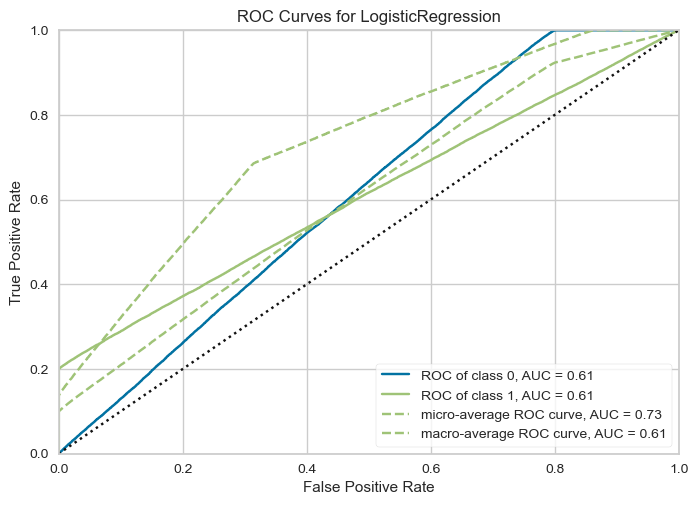

In [71]:
visualizer= roc_auc(LogisticRegression(),x_train, y_train)

In [72]:
from sklearn.tree import DecisionTreeClassifier

In [73]:
d=DecisionTreeClassifier()

In [74]:
d.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [75]:
dtahmin=d.predict(x_test)

In [76]:
accuracy_score(y_test,dtahmin)

0.7462303247271241

In [77]:
confusion_matrix(y_test,dtahmin)

array([[11083,  5076],
       [ 7967, 27271]])

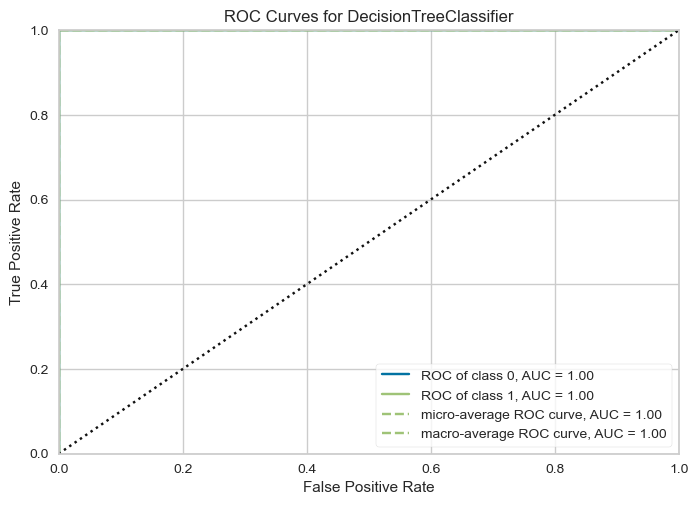

In [78]:
visualizer= roc_auc(DecisionTreeClassifier(),x_train, y_train)

In [79]:
from sklearn.ensemble import RandomForestClassifier

In [80]:
r=RandomForestClassifier()

In [81]:
rtahmin=r.fit(x_train,y_train).predict(x_test)

In [82]:
accuracy_score(y_test,rtahmin)

0.8253594567776329

In [83]:
confusion_matrix(y_test,rtahmin)

array([[10013,  6146],
       [ 2830, 32408]])

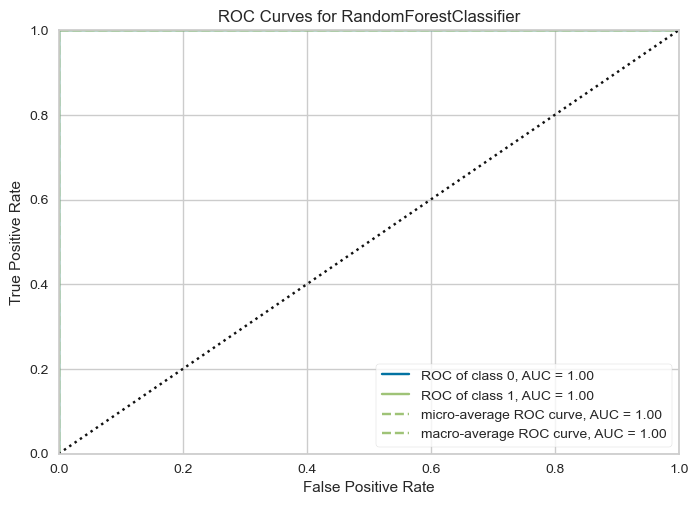

In [84]:
visualizer= roc_auc(RandomForestClassifier(),x_train, y_train)

In [85]:
from sklearn.neighbors import KNeighborsClassifier

In [86]:
k=KNeighborsClassifier()

In [87]:
ktahmin=r.fit(x_train,y_train).predict(x_test)

In [88]:
accuracy_score(y_test,ktahmin)

0.8264684709224274

In [89]:
confusion_matrix(y_test,ktahmin)

array([[10043,  6116],
       [ 2803, 32435]])

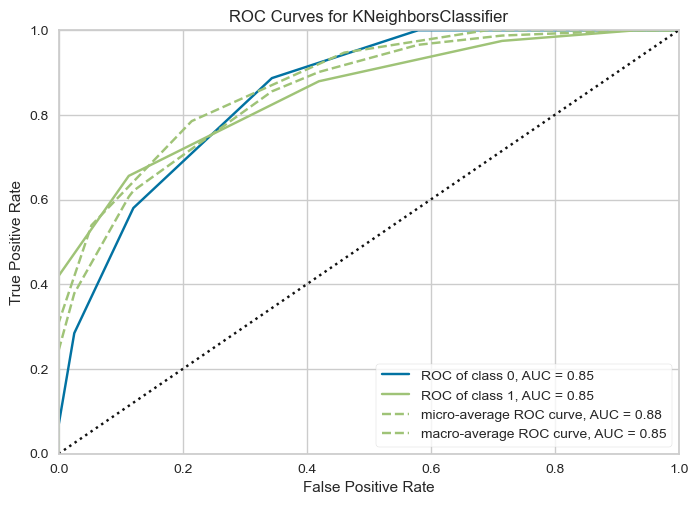

In [90]:
visualizer= roc_auc(KNeighborsClassifier(),x_train, y_train)

In [91]:
from sklearn.ensemble import GradientBoostingClassifier

In [92]:
h=GradientBoostingClassifier()

In [93]:
htahmin=r.fit(x_train,y_train).predict(x_test)

In [94]:
accuracy_score(y_test,htahmin)

0.8261377123178396

In [95]:
confusion_matrix(y_test,htahmin)

array([[10043,  6116],
       [ 2820, 32418]])

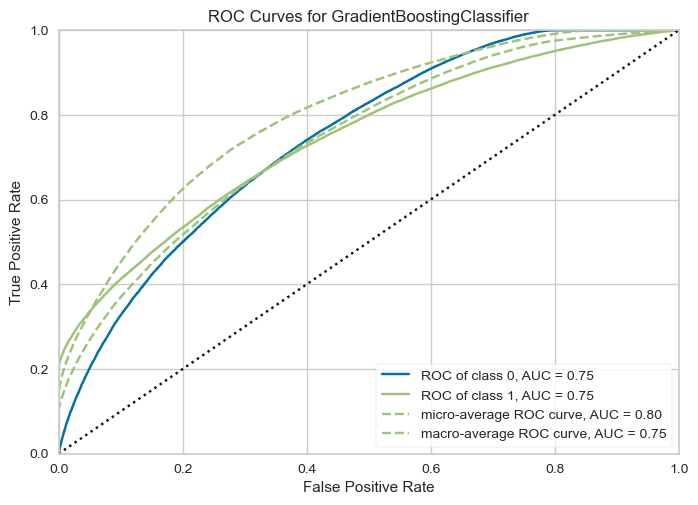

In [96]:
visualizer= roc_auc(GradientBoostingClassifier(),x_train, y_train)

In [97]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

b = BernoulliNB()
l = LogisticRegression()
d = DecisionTreeClassifier()
r = RandomForestClassifier()
gb= GradientBoostingClassifier()
kn= KNeighborsClassifier()
ab= AdaBoostClassifier()
mn= MultinomialNB()

def algo_test(x, y):
    modeller=[ b, l, d, r, gb, kn, ab, mn]
    isimler=["BernoulliNB", "LogisticRegression", "DecisionTreeClassifier", 
             "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
             "AdaBoostClassifier", "MultinomialNB"]

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.3, random_state = 42)
    
    accuracy = []
    precision = []
    recall = []
    f1 = []
    mdl=[]

    print("Veriler hazır modeller deneniyor")
    for model in modeller:
        print(model, " modeli eğitiliyor!..")
        model=model.fit(x_train,y_train)
        tahmin=model.predict(x_test)
        mdl.append(model)
        accuracy.append(accuracy_score(y_test, tahmin))
        precision.append(precision_score(y_test, tahmin, average="micro"))
        recall.append(recall_score(y_test, tahmin, average="micro"))
        f1.append(f1_score(y_test, tahmin, average="micro"))
        print(confusion_matrix(y_test, tahmin))

    print("Eğitim tamamlandı.")
    
    metrics=pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "F1", "Model"], index=isimler)
    metrics["Accuracy"] = accuracy
    metrics["Precision"] = precision  
    metrics["Recall"] = recall
    metrics["F1"] = f1
    metrics["Model"]=mdl

    metrics.sort_values("F1", ascending=False, inplace=True)

    print("En başarılı model: ", metrics.iloc[0].name)
    model=metrics.iloc[0,-1]
    tahmin=model.predict(np.array(x_test) if model==kn else x_test)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, tahmin))
    print("classification Report:")
    print(classification_report(y_test, tahmin))
    print("Diğer Modeller:")
    
    return metrics.drop("Model", axis=1)



In [98]:
algo_test(x,y)

Veriler hazır modeller deneniyor
BernoulliNB()  modeli eğitiliyor!..
[[    1 24321]
 [    0 52774]]
LogisticRegression()  modeli eğitiliyor!..


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[[    0 24322]
 [    0 52774]]
DecisionTreeClassifier()  modeli eğitiliyor!..
[[15883  8439]
 [12463 40311]]
RandomForestClassifier()  modeli eğitiliyor!..
[[14133 10189]
 [ 4573 48201]]
GradientBoostingClassifier()  modeli eğitiliyor!..
[[ 7415 16907]
 [ 4941 47833]]
KNeighborsClassifier()  modeli eğitiliyor!..
[[ 9595 14727]
 [10622 42152]]
AdaBoostClassifier()  modeli eğitiliyor!..
[[    0 24322]
 [    0 52774]]
MultinomialNB()  modeli eğitiliyor!..
[[23860   462]
 [41448 11326]]
Eğitim tamamlandı.
En başarılı model:  RandomForestClassifier
Confusion Matrix:
[[14133 10189]
 [ 4573 48201]]
classification Report:
              precision    recall  f1-score   support

           0       0.76      0.58      0.66     24322
           1       0.83      0.91      0.87     52774

    accuracy                           0.81     77096
   macro avg       0.79      0.75      0.76     77096
weighted avg       0.80      0.81      0.80     77096

Diğer Modeller:


,Accuracy,Precision,Recall,F1
RandomForestClassifier,0.808524,0.808524,0.808524,0.808524
DecisionTreeClassifier,0.728883,0.728883,0.728883,0.728883
GradientBoostingClassifier,0.716613,0.716613,0.716613,0.716613
BernoulliNB,0.684536,0.684536,0.684536,0.684536
LogisticRegression,0.684523,0.684523,0.684523,0.684523
AdaBoostClassifier,0.684523,0.684523,0.684523,0.684523
KNeighborsClassifier,0.671202,0.671202,0.671202,0.671202
MultinomialNB,0.456392,0.456392,0.456392,0.456392


En başarılı model 0.80 Accuracy ile RandomForestClassifier	olmuştur.

In [101]:
import pandas as pd

def musteri_mulakat_arayuzu():
    print("--- KREDİ BAŞVURU SORGULAMA EKRANI ---")
    print("Lütfen müşteriden alınan cevapları giriniz:\n")

    try:
        # 1. Mevcut Borçluluk (Credit Utilization)
        borc_orani = float(input("1. Aktif kredi limitlerinin kullanım yüzdesi (Örn: 30): "))
        
        # 2. Gelir İstikrarı (Job Stability)
        is_degistirme = int(input("2. Son 2 yıldaki iş değiştirme sayısı: "))
        
        # 3. Ödeme Alışkanlığı (Delinquency)
        gecikme_var_mi = input("3. 30 günü aşan gecikme yaşandı mı? (Evet/Hayır): ").lower()
        gecikme_skoru = 1 if gecikme_var_mi == 'evet' else 0
        
        # 4. Tasarruf Eğilimi (Savings Rate)
        tasarruf_orani = float(input("4. Aylık gelirin biriktirilen yüzdesi (Örn: 15): "))

        # Verileri bir sözlükte toplayalım
        yeni_veri = {
            'Credit_Utilization': [borc_orani / 100], # Yüzdeyi ondalığa çeviriyoruz
            'Job_Changes_2yrs': [is_degistirme],
            'Has_Late_Payments': [gecikme_skoru],
            'Savings_Rate': [tasarruf_orani / 100]
        }

        # Modelin okuyabileceği DataFrame formatına getiriyoruz
        musteri_df = pd.DataFrame(yeni_veri)
        
        print("\n--- GİRİŞ BAŞARILI ---")
        print("Müşteri Profil Özeti:")
        print(musteri_df)
        
        return musteri_df

    except ValueError:
        print("\n❌ HATA: Lütfen sayısal değerler için sadece rakam giriniz.")
        return None

# Fonksiyonu çalıştıralım
yeni_musteri = musteri_mulakat_arayuzu()


--- KREDİ BAŞVURU SORGULAMA EKRANI ---
Lütfen müşteriden alınan cevapları giriniz:



1. Aktif kredi limitlerinin kullanım yüzdesi (Örn: 30):  30
2. Son 2 yıldaki iş değiştirme sayısı:  2
3. 30 günü aşan gecikme yaşandı mı? (Evet/Hayır):  evet
4. Aylık gelirin biriktirilen yüzdesi (Örn: 15):  10



--- GİRİŞ BAŞARILI ---
Müşteri Profil Özeti:
   Credit_Utilization  Job_Changes_2yrs  Has_Late_Payments  Savings_Rate
0                 0.3                 2                  1           0.1
